<a href="https://colab.research.google.com/github/gabryellenpa/mecaniQA-belo_horizonte/blob/main/mecaniQA_belo_horizonte.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd
import numpy as np

def check_missing_values(dataframe):
    """
    Verifica e imprime a contagem de valores ausentes por coluna em um DataFrame.
    Retorna True se não houver valores ausentes, False caso contrário.
    """
    print("Contagem de valores ausentes por coluna:")
    missing_counts = dataframe.isnull().sum()
    print(missing_counts)
    total_missing = missing_counts.sum()
    if total_missing > 0:
        print(f"\nTotal de {total_missing} valores ausentes encontrados no DataFrame.")
        return False
    else:
        print("\nNenhum valor ausente encontrado no DataFrame.")
        return True

In [24]:
from google.colab import files
arquivo_enviado = files.upload


In [26]:
df = pd.read_csv('/content/mecaniQA-belo_horizonte.csv')

In [27]:
df.head()

,Data,Trocas_Oleo,Manutencao_Motor
0,2024-01-01,11.0,2.0
1,2024-01-02,21.0,13.0
2,2024-01-03,33.0,13.0
3,2024-01-04,25.0,14.0
4,2024-01-05,19.0,6.0


In [28]:
print("celulas ausentes")
print(df.isnull().sum())

celulas ausentes
Data                0
Trocas_Oleo         0
Manutencao_Motor    0
dtype: int64


In [29]:
colunas_numericas = df.select_dtypes(include="number").columns
print("colunas numericas")
print(colunas_numericas.tolist())


colunas numericas
['Trocas_Oleo', 'Manutencao_Motor']


In [30]:
colunas_outliers = ["Trocas_Oleo", "Manutencao_Motor"]
def tratar_outliers_iqr(df, colunas):
    df_limpo = df.copy()

    for coluna in colunas:
        Q1 = df_limpo[coluna].quantile(0.25)
        Q3 = df_limpo[coluna].quantile(0.75)
        IQR = Q3 - Q1

        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR

        quantidade = (
            (df_limpo[coluna] < limite_inferior) |
            (df_limpo[coluna] > limite_superior)
        ).sum()

        print(f"{coluna}: {quantidade} outlier(s)")
        print(f"Limites: {limite_inferior:.2f} a {limite_superior:.2f}\n")

        # Substitui os extremos pelos limites estatísticos
        df_limpo[coluna] = df_limpo[coluna].clip(
            lower=limite_inferior,
            upper=limite_superior
        )

    return df_limpo

In [31]:
df_limpo = tratar_outliers_iqr (df, colunas_outliers)
df.columns.tolist()

Trocas_Oleo: 0 outlier(s)
Limites: -4.50 a 55.50

Manutencao_Motor: 0 outlier(s)
Limites: -2.00 a 22.00



['Data', 'Trocas_Oleo', 'Manutencao_Motor']

In [32]:
print("ANTES DO TRATAMENTO:")
display(df[colunas_outliers].describe())

print("\nDEPOIS DO TRATAMENTO:")
display(df_limpo[colunas_outliers].describe())

ANTES DO TRATAMENTO:


,Trocas_Oleo,Manutencao_Motor
count,285.000000,285.000000
mean,25.564912,9.978947
std,10.725455,4.593272
min,2.000000,-2.000000
25%,18.000000,7.000000
50%,25.000000,10.000000
75%,33.000000,13.000000
max,53.000000,22.000000



DEPOIS DO TRATAMENTO:


,Trocas_Oleo,Manutencao_Motor
count,285.000000,285.000000
mean,25.564912,9.978947
std,10.725455,4.593272
min,2.000000,-2.000000
25%,18.000000,7.000000
50%,25.000000,10.000000
75%,33.000000,13.000000
max,53.000000,22.000000


In [34]:
for coluna in colunas_outliers:
    alterados = df[df[coluna] != df_limpo[coluna]][[coluna]].copy()
    alterados["Valor tratado"] = df_limpo.loc[alterados.index, coluna]

    print(f"\nAlterações em {coluna}:")
    display(alterados)


Alterações em Trocas_Oleo:


,Trocas_Oleo,Valor tratado



Alterações em Manutencao_Motor:


,Manutencao_Motor,Valor tratado


In [33]:
df_limpo.columns.tolist()

['Data', 'Trocas_Oleo', 'Manutencao_Motor']

In [35]:
df_limpo["Data"] = pd.to_datetime(
    df_limpo["Data"],
    dayfirst=True,
    errors="coerce"
)

df_limpo = df_limpo.sort_values("Data").reset_index(drop=True)

df_limpo[["Data"]].head()

,Data
0,2024-01-01
1,2024-01-02
2,2024-01-03
3,2024-01-04
4,2024-01-05


In [36]:
df_limpo["Data"].isnull().sum()

np.int64(0)

In [37]:
check_missing_values(df_limpo)

Contagem de valores ausentes por coluna:
Data                0
Trocas_Oleo         0
Manutencao_Motor    0
dtype: int64

Nenhum valor ausente encontrado no DataFrame.


True

In [38]:
df_limpo.dropna(inplace=True)
print("Após a remoção das linhas com valores ausentes:")
check_missing_values(df_limpo)

Após a remoção das linhas com valores ausentes:
Contagem de valores ausentes por coluna:
Data                0
Trocas_Oleo         0
Manutencao_Motor    0
dtype: int64

Nenhum valor ausente encontrado no DataFrame.


True

In [39]:
df_limpo.head()

,Data,Trocas_Oleo,Manutencao_Motor
0,2024-01-01,11.0,2.0
1,2024-01-02,9.0,4.0
2,2024-01-03,12.0,1.0
3,2024-01-04,15.0,8.0
4,2024-01-05,25.0,10.0


In [40]:
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285 entries, 0 to 284
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Data              285 non-null    datetime64[ns]
 1   Trocas_Oleo       285 non-null    float64       
 2   Manutencao_Motor  285 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 6.8 KB


In [41]:
df_limpo.to_csv('mecaniQA-belo_horizonte.csv', index=False)

In [42]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

In [43]:
serie_temporal = df_limpo[["Data", "Trocas_Oleo"]].copy()

serie_temporal.set_index("Data", inplace=True)

serie_temporal.head()

,Trocas_Oleo
Data,
2024-01-01,11.0
2024-01-02,9.0
2024-01-03,12.0
2024-01-04,15.0
2024-01-05,25.0


In [44]:
print(
    serie_temporal.index
    .to_series()
    .diff()
    .value_counts()
    .head()
)

Data
1 days     261
20 days     13
19 days      7
18 days      1
22 days      1
Name: count, dtype: int64


In [45]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

In [46]:
decomposicao = seasonal_decompose(
    serie_temporal["Trocas_Oleo"],
    model="additive",
    period=7
)

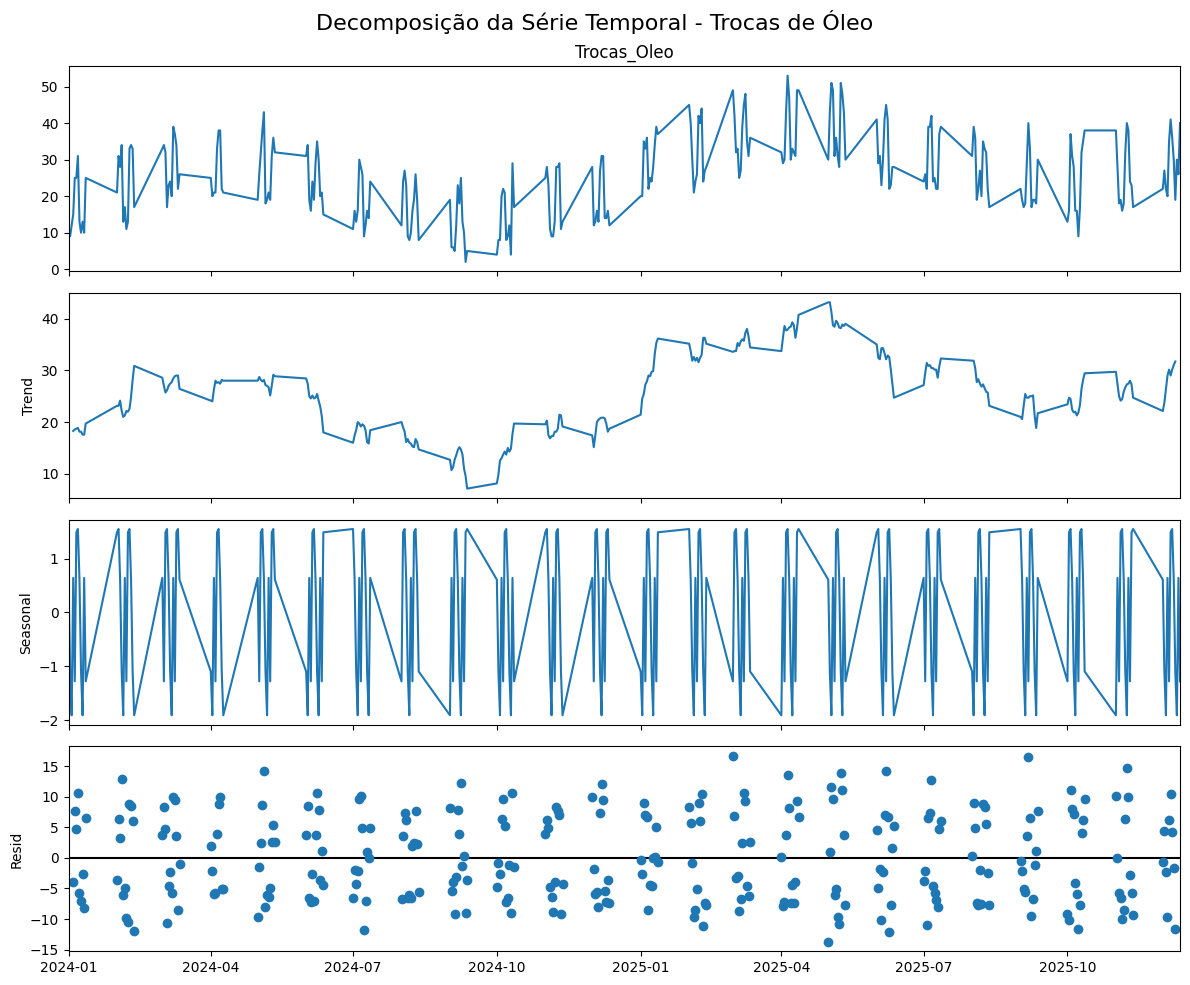

In [47]:
fig = decomposicao.plot()

fig.set_size_inches(12, 10)

plt.suptitle(
    "Decomposição da Série Temporal - Trocas de Óleo",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Análise da Decomposição

Foi utilizada uma decomposição aditiva da série temporal de `Trocas_Oleo`,
considerando um período de 7 observações para analisar a sazonalidade semanal.

Os resultados mostram:

- **Observed:** os valores originais de trocas de óleo;
- **Trend:** a evolução do volume de trocas ao longo do tempo;
- **Seasonal:** o comportamento que se repete ao longo da semana;
- **Residual:** variações não explicadas pela tendência e pela sazonalidade.

A decomposição permite compreender melhor o comportamento histórico da oficina
antes da construção do modelo preditivo.